# Exponential Decay Model — NYC COVID-19 Daily Cases

**Data:** Daily COVID-19 case counts in New York City every 5 days, April 1 – June 26, 2020.

**Model:** $y = Ae^{kx}$, where $k < 0$ (exponential decay)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90])
y = np.array([5450, 6376, 3730, 3525, 3062, 1063, 1880, 1401, 1231, 490,
              1067, 1053, 664, 246, 353, 412, 150, 68])

def exp_model(x, A, k):
    return A * np.exp(k * x)

popt, _ = curve_fit(exp_model, x, y, p0=[6000, -0.05], maxfev=10000)
A, k = popt

y_pred = exp_model(x, A, k)
ss_res = np.sum((y - y_pred)**2)
r2 = 1 - ss_res / np.sum((y - y.mean())**2)
rmse = np.sqrt(np.mean((y - y_pred)**2))

print(f"Fitted model:  y = {A:.2f} * e^({k:.5f} * x)")
print(f"R\u00b2   = {r2:.4f}")
print(f"RMSE = {rmse:.2f}")

Fitted model:  y = 7647.30 * e^(-0.04169 * x)
R²   = 0.9245
RMSE = 501.11


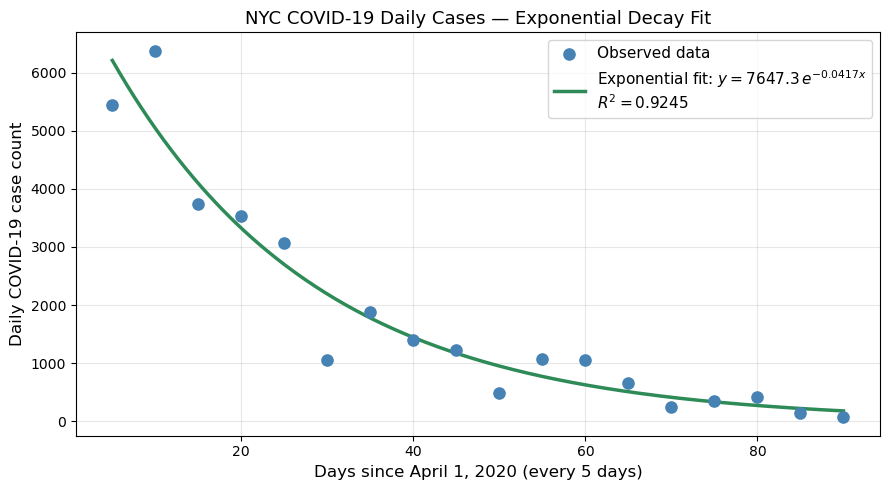

In [2]:
x_line = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color='steelblue', s=65, zorder=3, label='Observed data')
ax.plot(x_line, exp_model(x_line, A, k), color='seagreen', linewidth=2.5,
        label=f'Exponential fit: $y = {A:.1f}\\,e^{{{k:.4f}x}}$\n$R^2 = {r2:.4f}$')
ax.set_xlabel('Days since April 1, 2020 (every 5 days)', fontsize=12)
ax.set_ylabel('Daily COVID-19 case count', fontsize=12)
ax.set_title('NYC COVID-19 Daily Cases \u2014 Exponential Decay Fit', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

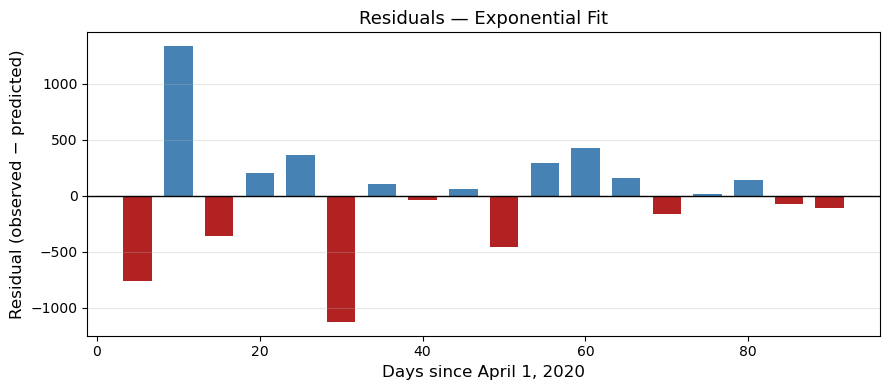

In [3]:
residuals = y - y_pred

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, residuals, width=3.5,
       color=['firebrick' if r < 0 else 'steelblue' for r in residuals])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Days since April 1, 2020', fontsize=12)
ax.set_ylabel('Residual (observed \u2212 predicted)', fontsize=12)
ax.set_title('Residuals \u2014 Exponential Fit', fontsize=13)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Results

| Parameter | Meaning |
|---|---|
| $A$ | Estimated case count extrapolated to $x=0$ |
| $k < 0$ | Confirms declining epidemic phase |
| $R^2$ | Proportion of variance explained by the model |
| RMSE | Average prediction error in case counts |

The exponential model is more appropriate than linear because case counts are always positive — the curve asymptotes toward zero rather than crossing into negative values. The decay rate $k$ reflects the effect of interventions (lockdowns, social distancing) slowing transmission over this period.